In [ ]:
#import necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#control the display of maximum number of columns in the dataframe
pd.set_option('display.max_columns', 25)

In [ ]:
#display the dataset(csv- comma separated value file)
df = pd.read_csv('/content/drive/MyDrive/booksdataset.csv')
df.head()

,title,author,rating,description,language,genres,pages,publisher,publishDate,likedPercent,coverImg,price
0,The Hunger Games,Suzanne Collins,4.33,WINNING MEANS FAME AND FORTUNE.LOSING MEANS CE...,English,"['Young Adult', 'Fiction', 'Dystopia', 'Fantas...",374,Scholastic Press,09-14-08,96.0,https://i.gr-assets.com/images/S/compressed.ph...,5.09
1,Harry Potter and the Order of the Phoenix,"J.K. Rowling, Mary GrandPré (Illustrator)",4.50,There is a door at the end of a silent corrido...,English,"['Fantasy', 'Young Adult', 'Fiction', 'Magic',...",870,Scholastic Inc.,09-28-04,98.0,https://i.gr-assets.com/images/S/compressed.ph...,7.38
2,To Kill a Mockingbird,Harper Lee,4.28,The unforgettable novel of a childhood in a sl...,English,"['Classics', 'Fiction', 'Historical Fiction', ...",324,Harper Perennial Modern Classics,05-23-06,95.0,https://i.gr-assets.com/images/S/compressed.ph...,NaN
3,Pride and Prejudice,"Jane Austen, Anna Quindlen (Introduction)",4.26,Alternate cover edition of ISBN 9780679783268S...,English,"['Classics', 'Fiction', 'Romance', 'Historical...",279,Modern Library,10-10-2000,94.0,https://i.gr-assets.com/images/S/compressed.ph...,NaN
4,Twilight,Stephenie Meyer,3.60,About three things I was absolutely positive.\...,English,"['Young Adult', 'Fantasy', 'Romance', 'Vampire...",501,"Little, Brown and Company",09-06-2006,78.0,https://i.gr-assets.com/images/S/compressed.ph...,2.1


In [ ]:
#rename some columns
df.rename(columns={'genres':'genre', 'publishDate':'publishyear', 'likedPercent':'likedpercent',
                   'coverImg':'coverimage', 'pages':'page'}, inplace=True)

In [ ]:
#rearrange the columns in the specific order
column_order = ['title', 'description', 'author', 'genre', 'language', 'rating', 'likedpercent', 'page',
                 'publisher', 'publishyear', 'price', 'coverimage']
df = df[column_order]
df.head(1)

,title,description,author,genre,language,rating,likedpercent,page,publisher,publishyear,price,coverimage
0,The Hunger Games,WINNING MEANS FAME AND FORTUNE.LOSING MEANS CE...,Suzanne Collins,"['Young Adult', 'Fiction', 'Dystopia', 'Fantas...",English,4.33,96.0,374,Scholastic Press,09-14-08,5.09,https://i.gr-assets.com/images/S/compressed.ph...


In [ ]:
df.shape

(52478, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52478 entries, 0 to 52477
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         52478 non-null  object 
 1   description   51140 non-null  object 
 2   author        52478 non-null  object 
 3   genre         52478 non-null  object 
 4   language      48672 non-null  object 
 5   rating        52478 non-null  float64
 6   likedpercent  51856 non-null  float64
 7   page          50131 non-null  object 
 8   publisher     48782 non-null  object 
 9   publishyear   51598 non-null  object 
 10  price         38113 non-null  object 
 11  coverimage    51873 non-null  object 
dtypes: float64(2), object(10)
memory usage: 4.8+ MB


In [ ]:
import re

In [ ]:
#ensure 'description' column contains only strings
df['description'] = df['description'].astype(str)
#remove special characters, numbers, and extra whitespaces from the 'description' column
df['description'] = df['description'].apply(lambda x: re.sub('[^a-zA-Z\s]', '', x))
df['description'].head(20)

0     WINNING MEANS FAME AND FORTUNELOSING MEANS CER...
1     There is a door at the end of a silent corrido...
2     The unforgettable novel of a childhood in a sl...
3     Alternate cover edition of ISBN Since its imme...
4     About three things I was absolutely positive\n...
5     Librarians note An alternate cover edition can...
6     Librarians note There is an Alternate Cover Ed...
7     Journeys to the end of the world fantastic cre...
8     This fourvolume boxed set contains JRR Tolkien...
9     Scarlett OHara the beautiful spoiled daughter ...
10    Despite the tumorshrinking medical miracle tha...
11    Seconds before the Earth is demolished to make...
12    Once there was a treeand she loved a little bo...
13    You can find the redesigned cover of this edit...
14    ISBN  moved to this editionWhile in Paris Harv...
15    A literary sensation and runaway bestseller th...
16    Written in his distinctively dazzling manner O...
17    I cant explain myself Im afraid sir said A

In [ ]:
# Display the entire column
pd.set_option('display.max_colwidth', None)

In [ ]:
# Capitalize the first letter of each sentence
df['description'] = df['description'].apply(lambda x: '. '.join([s.capitalize() for s in x.split('. ')]))
df['description'].head(1)

0    Winning means fame and fortunelosing means certain deaththe hunger games have begun   in the ruins of a place once known as north america lies the nation of panem a shining capitol surrounded by twelve outlying districts the capitol is harsh and cruel and keeps the districts in line by forcing them all to send one boy and once girl between the ages of twelve and eighteen to participate in the annual hunger games a fight to the death on live tvsixteenyearold katniss everdeen regards it as a death sentence when she steps forward to take her sisters place in the games but katniss has been close to dead beforeand survival for her is second nature without really meaning to she becomes a contender but if she is to win she will have to start making choices that weight survival against humanity and life against love
Name: description, dtype: object

In [ ]:
# Extract the first two words from the 'author' column
df['author'] = df['author'].str.split().str[:2].str.join(' ')
df['author'] = df['author'].str.replace(',', '')
df['author'] = df['author'].str.replace('.', '')
df['author'].head(20)

0       Suzanne Collins
1            JK Rowling
2            Harper Lee
3           Jane Austen
4       Stephenie Meyer
5          Markus Zusak
6         George Orwell
7              CS Lewis
8           JRR Tolkien
9     Margaret Mitchell
10           John Green
11        Douglas Adams
12     Shel Silverstein
13         Emily Brontë
14            Dan Brown
15        Arthur Golden
16          Oscar Wilde
17        Lewis Carroll
18     Charlotte Brontë
19          Victor Hugo
Name: author, dtype: object

In [ ]:
#remove '[]' from the genres
df['genre'] = df['genre'].str.strip("[]")
df = df.drop(df[df['genre'] == ''].index[0])
df['genre'].head(2)

0              'Young Adult', 'Fiction', 'Dystopia', 'Fantasy', 'Science Fiction', 'Romance', 'Adventure', 'Teen', 'Post Apocalyptic', 'Action'
1    'Fantasy', 'Young Adult', 'Fiction', 'Magic', 'Childrens', 'Adventure', 'Audiobook', 'Middle Grade', 'Classics', 'Science Fiction Fantasy'
Name: genre, dtype: object

In [ ]:
#remove the word 'pages' and convert from object to int datatype
df['page'] = df['page'].str.extract('(\d+)').fillna(0).astype('int32')
#convert 'price' column from object to float datatype
df['price'] = df['price'].str.extract('(\d+)').astype('float')
df[['page', 'price']].head(10)

,page,price
0,374,5.0
1,870,7.0
2,324,NaN
3,279,NaN
4,501,2.0
5,552,3.0
6,141,4.0
7,767,NaN
8,1728,21.0
9,1037,5.0


In [ ]:
#convert 'publishyear' column from object to datetime datatype
df['publishyear'] = pd.to_datetime(df['publishyear'], errors='coerce')
#display only the year from the whole date given
df['publishyear'] = pd.to_datetime(df['publishyear'], errors='coerce')
#extract the year from the 'publishyear' column
df['publishyear'] = df['publishyear'].dt.year
df['publishyear']

0        2008.0
1        2004.0
2        2006.0
3        2000.0
4        2006.0
          ...  
52473    2011.0
52474    2011.0
52475    2011.0
52476    2011.0
52477    2011.0
Name: publishyear, Length: 52477, dtype: float64

In [ ]:
#convert the 'publishyear' column to int32 datatype
#replace NaN with 0 or another appropriate value
df['publishyear'].fillna(0, inplace=True)
df['publishyear'] = df['publishyear'].astype('int32')

In [ ]:
#include values having more than 0 pages
df = df[df['page'] > 0]

In [ ]:
#check how many unique values every column consists of
df.nunique()

title           47594
description     47984
author          21931
genre           42821
language           80
rating            259
likedpercent       66
page             1364
publisher       10647
publishyear       104
price             243
coverimage      49586
dtype: int64

In [ ]:
df=df.dropna()

In [ ]:
df = df.drop_duplicates()
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
Int64Index: 34974 entries, 0 to 52477
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         34974 non-null  object 
 1   description   34974 non-null  object 
 2   author        34974 non-null  object 
 3   genre         34974 non-null  object 
 4   language      34974 non-null  object 
 5   rating        34974 non-null  float64
 6   likedpercent  34974 non-null  float64
 7   page          34974 non-null  int32  
 8   publisher     34974 non-null  object 
 9   publishyear   34974 non-null  int32  
 10  price         34974 non-null  float64
 11  coverimage    34974 non-null  object 
dtypes: float64(3), int32(2), object(7)
memory usage: 3.2+ MB


(34974, 12)

In [ ]:
df.nunique()

title           33673
description     34516
author          15466
genre           32274
language           50
rating            239
likedpercent       57
page             1205
publisher        6286
publishyear        91
price             237
coverimage      34974
dtype: int64

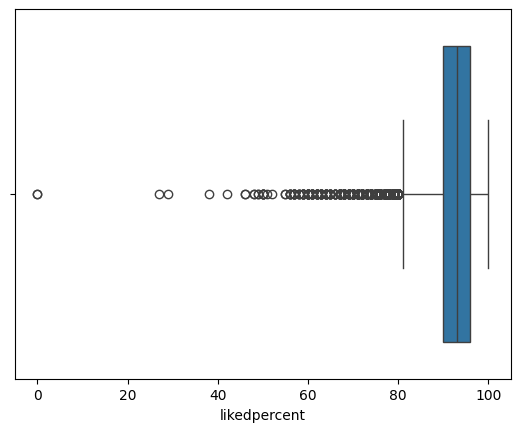

In [ ]:
#checking outliers for 'likedpercent' column
sns.boxplot(x=df['likedpercent'])
plt.show()

In [ ]:
df = df[df['title'].str.isalpha()]

In [ ]:
df.shape

(4021, 14)

In [ ]:
from textblob import TextBlob

In [ ]:
#mapping of sentiment polarity to categories
# Map sentiment polarity to emotion categories
df['sentiment'] = df['description'].apply(lambda x: TextBlob(x).sentiment.polarity)
df['sentiment'] = pd.cut(df['sentiment'], bins=[-1, -0.5, -0.2, 0.2, 0.5, 1],
                                  labels=['sad', 'angry', 'fear', 'happy', 'love'], include_lowest=True)
df[['title', 'description', 'sentiment']].head(50)

,title,description,sentiment
4,Twilight,About three things i was absolutely positive\n\nfirst edward was a vampire\n\nsecond there was a part of himand i didnt know how dominant that part might bethat thirsted for my blood\n\nand third i was unconditionally and irrevocably in love with him\n\ndeeply seductive and extraordinarily suspenseful twilight is a love story with bite,fear
21,Divergent,In beatrice priors dystopian chicago world society is divided into five factions each dedicated to the cultivation of a particular virtuecandor the honest abnegation the selfless dauntless the brave amity the peaceful and erudite the intelligent on an appointed day of every year all sixteenyearolds must select the faction to which they will devote the rest of their lives for beatrice the decision is between staying with her family and being who she really isshe cant have both so she makes a choice that surprises everyone including herselfduring the highly competitive initiation that follows beatrice renames herself tris and struggles alongside her fellow initiates to live out the choice they have made together they must undergo extreme physical tests of endurance and intense psychological simulations some with devastating consequences as initiation transforms them all tris must determine who her friends really areand where exactly a romance with a sometimes fascinating sometimes exasperating boy fits into the life shes chosen but tris also has a secret one shes kept hidden from everyone because shes been warned it can mean death and as she discovers unrest and growing conflict that threaten to unravel her seemingly perfect society she also learns that her secret might help her save those she loves or it might destroy her,fear
37,Dracula,You can find an alternative cover edition for this isbn here and herea rich selection of background and source materials is provided in three areas contexts includes probable inspirations for dracula in the earlier works of james malcolm rymer and emily gerard also included are a discussion of stokers working notes for the novel and draculas guest the original opening chapter to dracula reviews and reactions reprints five early reviews of the novel dramatic and film variations focuses on theater and film adaptations of dracula two indications of the novels unwavering appeal david j skal gregory a waller and nina auerbach offer their varied perspectives checklists of both dramatic and film adaptations are includedcriticism collects seven theoretical interpretations of dracula by phyllis a roth carol a senf franco moretti christopher craft bram dijkstra stephen d arata and talia schaffera chronology and a selected bibliography are included,fear
63,Dune,Set on the desert planet arrakis dune is the story of the boy paul atreides heir to a noble family tasked with ruling an inhospitable world where the only thing of value is the spice melange a drug capable of extending life and enhancing consciousness coveted across the known universe melange is a prize worth killing forwhen house atreides is betrayed the destruction of pauls family will set the boy on a journey toward a destiny greater than he could ever have imagined and as he evolves into the mysterious man known as muaddib he will bring to fruition humankinds most ancient and unattainable dream,happy
74,Outlander,The year is claire randall a former combat nurse is just back from the war and reunited with her husband on a second honeymoon when she walks through a standing stone in one of the ancient circles that dot the british isles suddenly she is a sassenachan outlanderin a scotland torn by war and raiding border clans in the year of our lord hurled back in time by forces she cannot understand claire is catapulted into the intrigues of lairds and spies that may threaten her life and shatter her heart for here james fraser a gallant young scots warrior shows her a love so absolute that claire becomes a woman torn between fidelity and desireand between two

In [ ]:
#finding correlations between each feature
correlation_matrix = df.corr()
correlation_matrix

,rating,likedpercent,page,publishyear,price
rating,1.000000,0.880084,0.159748,-0.001031,0.094128
likedpercent,0.880084,1.000000,0.118844,-0.003648,0.056939
page,0.159748,0.118844,1.000000,0.021031,0.027972
publishyear,-0.001031,-0.003648,0.021031,1.000000,-0.023089
price,0.094128,0.056939,0.027972,-0.023089,1.000000


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
label_encoder = LabelEncoder()
df['encoded_sentiment'] = label_encoder.fit_transform(df['sentiment'])
df[['encoded_sentiment', 'sentiment']].head(60)

,encoded_sentiment,sentiment
4,1,fear
21,1,fear
37,1,fear
63,2,happy
74,1,fear
76,1,fear
107,1,fear
113,1,fear
138,1,fear
140,1,fear


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
X = df[['rating', 'encoded_sentiment']]
y = df['likedpercent']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [ ]:
#standardize numerical features
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [ ]:
#linear regression for continuous target variable
model=LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
#predict on test set
y_pred=model.predict(X_test_scaled)

In [ ]:
#evaluate the model using means squared error
mse=mean_squared_error(y_test, y_pred)
print(f'mean squared error: {mse:.2f}')

mean squared error: 6.96


In [ ]:
#display coefficient
coefficients=pd.DataFrame({'feature':X.columns, 'coefficient':model.coef_})
print(coefficients)

             feature  coefficient
0             rating     4.769086
1  encoded_sentiment    -0.139175


In [ ]:
#display intercept
intercept=model.intercept_
print(f'intercept:{intercept}')

intercept:91.12126865671642


In [ ]:
#decision tree regressor
from sklearn.tree import DecisionTreeRegressor

In [ ]:
model=DecisionTreeRegressor()
model.fit(X_train_scaled, y_train)

DecisionTreeRegressor()

In [ ]:
#predict on test set
y_pred=model.predict(X_test_scaled)

In [ ]:
#evaluate the model
mse=mean_squared_error(y_test, y_pred)
print(f'mean squared error: {mse:.2f}')
r2=r2_score(y_test, y_pred)
print(f'r-squared: {r2:.2f}')

mean squared error: 5.44
r-squared: 0.82


In [ ]:
#support vector machine
from sklearn.svm import SVR

In [ ]:
model=SVR(kernel='linear')
model.fit(X_train_scaled, y_train)

SVR(kernel='linear')

In [ ]:
#predict on test set
y_pred=model.predict(X_test_scaled)

In [ ]:
#evaluate the model
mse=mean_squared_error(y_test, y_pred)
print(f'mean squared error: {mse:.2f}')
r2=r2_score(y_test, y_pred)
print(f'r-squared: {r2:.2f}')

mean squared error: 7.24
r-squared: 0.76


In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
model=RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred=model.predict(X_test)

In [ ]:
#evaluate the model
mse=mean_squared_error(y_test, y_pred)
print(f'mean squared error: {mse:.2f}')
r2=r2_score(y_test, y_pred)
print(f'r-squared: {r2:.2f}')

mean squared error: 5.16
r-squared: 0.83


In [ ]:
#user input
book_sentiment = input("encoded_sentiment: ")
user_rating = float(input("rating: "))
user_likedpercent = input("likedpercent: ")

encoded_sentiment: love
rating: 4
likedpercent: 90


In [ ]:
#preprocess user input
user_input = pd.DataFrame({
    'encoded_sentiment': [book_sentiment],
    'rating': [user_rating],
    'likedpercent': [user_likedpercent],
})

In [ ]:
# Ensure the 'encoded_sentiment' column is treated as a category with one-hot encoding
user_input['encoded_sentiment'] = pd.Categorical(user_input['encoded_sentiment'], categories=X['encoded_sentiment'].cat.categories, ordered=False)
user_input_encoded = pd.get_dummies(user_input, columns=['encoded_sentiment'], drop_first=True)

# Ensure the user input DataFrame has the same columns as the training data
missing_columns = set(X.columns) - set(user_input_encoded.columns)
for column in missing_columns:
    user_input_encoded[column] = 0

# Reorder columns to match the training data
user_input_encoded = user_input_encoded[X.columns]

# Predict LikedPercent for user input
predicted_liked_percent = model.predict(user_input_encoded)[0]

# Recommend books based on predicted LikedPercent
recommended_books = df[df['likedpercent'] >= predicted_liked_percent]['title']

print(f'Recommended Books based on LikedPercent: {recommended_books.tolist()}')

TypeError: list indices must be integers or slices, not str

In [ ]:
'''user_input_sentiment = user_input['sentiment'].values
#use the label encoder to transform the 'sentiment' column in the user input
user_input_encoded = label_encoder.transform(user_input_sentiment)
#replace the original 'sentiment' column with the encoded values
user_input['sentiment'] = user_input_encoded
print(user_input)'''

In [ ]:
'''#recommend books based on liked percent
recommended_books = df[df['likedpercent'] == user_input_encoded[0]]'''

In [ ]:
'''from bs4 import BeautifulSoup
from IPython.display import Image, display'''

In [ ]:
'''for index, row in recommended_books.iterrows():
    # Display the book details including cover image and publish year
    display(Image(url=row['coverimg'], width=130, height=150))
    print(f"Title: {row['title']}")
    print(f"Author: {row['author']}")
    print(f"Rating: {row['rating']}")
    print(f"Sentiment: {row['sentiment']}")
    print("\n")'''